In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("arjunbasandrai/25-indian-bird-species-with-226k-images")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 9.33G/9.33G [01:50<00:00, 91.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4):
['training_data', 'training_set']


In [ ]:
print(f"Contents of the 'training_set' directory: {os.listdir(os.path.join(path, 'training_set'))}")
print(f"Contents of the 'training_data' directory: {os.listdir(os.path.join(path, 'training_data'))}")

Contents of the 'training_set' directory: ['training_set']
Contents of the 'training_data' directory: ['val', 'train', 'test']



--- Sample Images from training_set (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set) ---
Found 22620 images in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set. Displaying 6 samples:


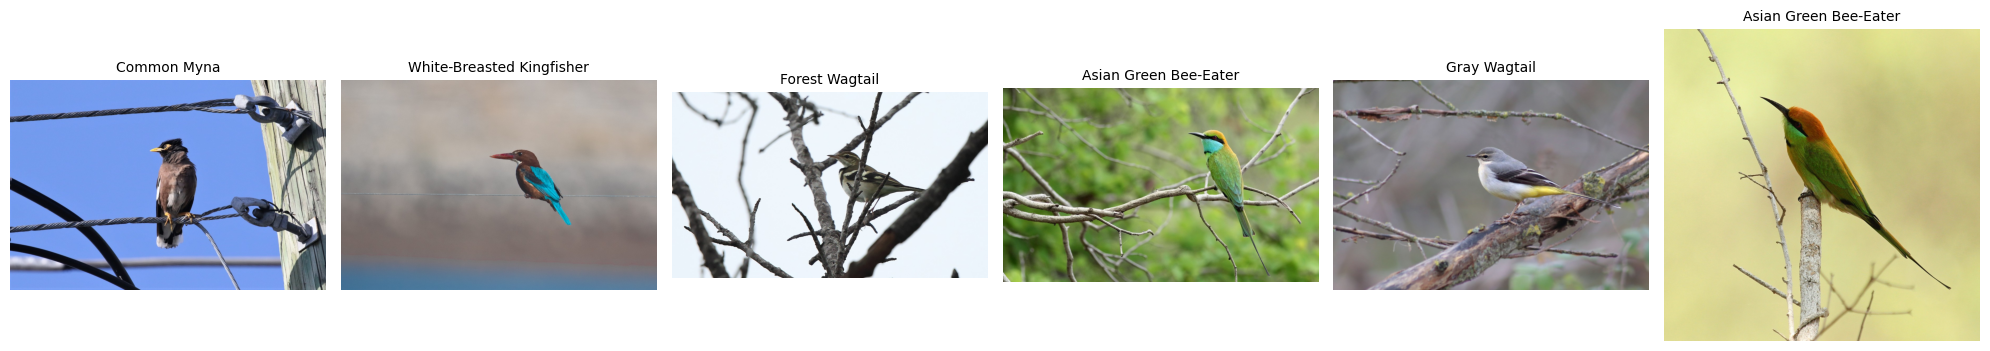


--- Sample Images from training_data (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data) ---
No images found in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Extract species name from the directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to use the actual dataset folders found in cell IXEO7kTkTmB8
training_set_path = os.path.join(path, 'training_set')
print(f"\n--- Sample Images from training_set ({training_set_path}) ---")
display_sample_images(training_set_path)

training_data_path = os.path.join(path, 'training_data')
print(f"\n--- Sample Images from training_data ({training_data_path}) ---")
display_sample_images(training_data_path)


In [ ]:
import os

# Define the actual path containing the bird species folders
# Based on previous results, it is located in training_set/training_set
input_folder = os.path.join(path, 'training_set', 'training_set')
output_folder = '/content/bird_dataset_split'

if not os.path.exists(input_folder):
    # Fallback if the directory structure is not nested
    input_folder = os.path.join(path, 'training_set')

print(f"Preparing to split data from: {input_folder}")

Preparing to split data from: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set/training_set


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Split the dataset: train=0.8, test=0.2
# seed=42 to ensure reproducibility
# We are splitting into train and val (using val as the test set as requested)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Data split successfully into folder: {output_folder}")

Copying files: 22620 files [00:41, 540.00 files/s]

Data split successfully into folder: /content/bird_dataset_split


In [ ]:
# Check the directory structure after splitting
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 2: # Only print up to species level to avoid long output
        print(f"{indent}{os.path.basename(root)}/")

bird_dataset_split/
    val/
        White-Breasted Kingfisher/
        Rufous Treepie/
        Red-Wattled Lapwing/
        Cattle Egret/
        Coppersmith Barbet/
        Gray Wagtail/
        White Wagtail/
        Indian Pitta/
        Hoopoe/
        Common Kingfisher/
        Forest Wagtail/
        Common Myna/
        Asian Green Bee-Eater/
        Ruddy Shelduck/
        Brown-Headed Barbet/
        Common Rosefinch/
        Jungle Babbler/
        House Crow/
        Northern Lapwing/
        Indian Peacock/
        Sarus Crane/
        Indian Grey Hornbill/
        Common Tailorbird/
        White-Breasted Waterhen/
        Indian Roller/
    train/
        White-Breasted Kingfisher/
        Rufous Treepie/
        Red-Wattled Lapwing/
        Cattle Egret/
        Coppersmith Barbet/
        Gray Wagtail/
        White Wagtail/
        Indian Pitta/
        Hoopoe/
        Common Kingfisher/
        Forest Wagtail/
        Common Myna/
        Asian Green Bee-Eater/
     

In [ ]:
import os

def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"New dataset statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%)")
print(f"- Total: {total} images")

New dataset statistics:
- Train Set: 18090 images (80.0%)
- Test Set (val): 4530 images (20.0%)
- Total: 22620 images


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Data transformation for AlexNet (requires 224x224 input)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(output_folder, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(output_folder, 'val'), data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=64, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=64, shuffle=False, num_workers=2)
}

# Build AlexNet model
model = models.alexnet(weights=None)
num_ftrs = model.classifier[6].in_features
# The dataset has 25 species
model.classifier[6] = nn.Linear(num_ftrs, 25)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Training...")
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f'Epoch {epoch+1}/{num_epochs} | {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Starting Training...
Epoch 1/10 | train Loss: 3.1250 Acc: 0.0713
Epoch 1/10 | val Loss: 2.9354 Acc: 0.1329
Epoch 2/10 | train Loss: 2.8151 Acc: 0.1559
Epoch 2/10 | val Loss: 2.6757 Acc: 0.1987
Epoch 3/10 | train Loss: 2.5718 Acc: 0.2320
Epoch 3/10 | val Loss: 2.4305 Acc: 0.2777
Epoch 4/10 | train Loss: 2.3675 Acc: 0.2971
Epoch 4/10 | val Loss: 2.1850 Acc: 0.3402
Epoch 5/10 | train Loss: 2.1605 Acc: 0.3548
Epoch 5/10 | val Loss: 1.9687 Acc: 0.4044
Epoch 6/10 | train Loss: 1.9617 Acc: 0.4197
Epoch 6/10 | val Loss: 1.9928 Acc: 0.4060
Epoch 7/10 | train Loss: 1.8017 Acc: 0.4606
Epoch 7/10 | val Loss: 1.7030 Acc: 0.4872
Epoch 8/10 | train Loss: 1.6753 Acc: 0.4977
Epoch 8/10 | val Loss: 1.5414 Acc: 0.5426
Epoch 9/10 | train Loss: 1.5513 Acc: 0.5364
Epoch 9/10 | val Loss: 1.4973 Acc: 0.5442
Epoch 10/10 | train Loss: 1.4835 Acc: 0.5534
Epoch 10/10 | val Loss: 1.4609 Acc: 0.5695


In [ ]:
print("Training Summary:")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Best Validation Accuracy: {max(history['val_acc']):.4f}")

Training Summary:
Final Training Accuracy: 0.5534
Final Validation Accuracy: 0.5695
Best Validation Accuracy: 0.5695


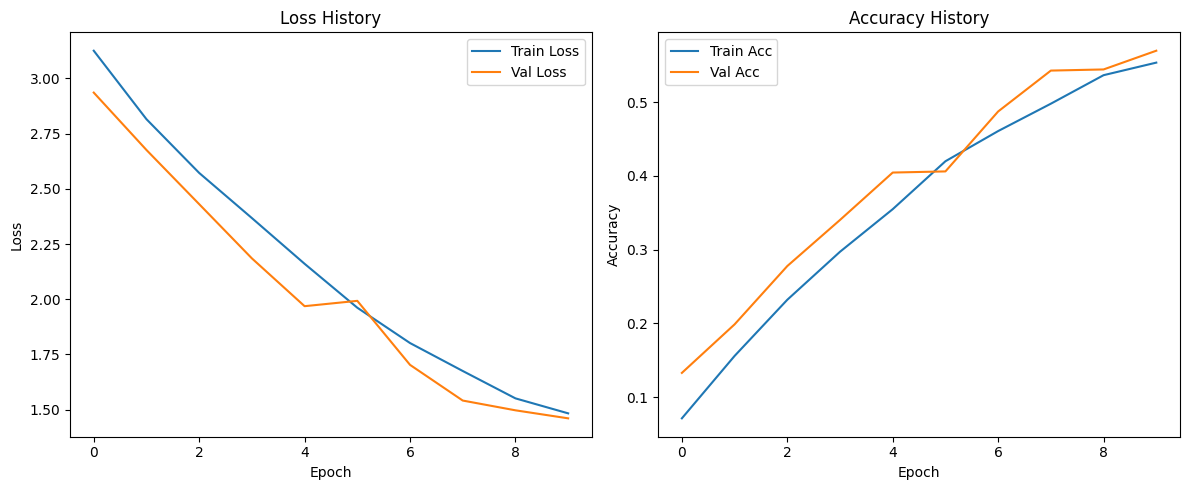

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()